# CASPER — Official Source Code Walkthrough
**Paper:** Islam et al., *Detecting Compromise of Passkey Storage on the Cloud*, USENIX Security 2025
**Official repo:** [github.com/islamazhar/CASPER](https://github.com/islamazhar/CASPER)

This notebook is a faithful **Python translation** of the authors' Go prototype
(`lib.go`, `casper_login_test.go`, `casper_detection_test.go`) plus a Python
simulation of their PRISM POMDP models (`passkey_tdp.prism`, `passkey_eff_std2.prism`).
WebAuthn ceremonies follow W3C WebAuthn Level 2 and FIDO2 industry standards.

| Section | Maps to |
|---|---|
| 1. Setup & constants | `lib.go` + W3C WebAuthn spec |
| 2. Core primitives | `lib.go` functions |
| 2b. WebAuthn ceremony helpers | W3C WebAuthn Level 2 / FIDO2 |
| 2c. User secret η | Paper appendix "More about User Secret η" |
| 3. `TestCasperLogin` | `casper_login_test.go` |
| 4. `TestCasperDetection` | `casper_detection_test.go` |
| 4b. Flatness preservation | Security property (why offline attack fails) |
| 5. PRISM TDP model | `passkey_tdp.prism` |
| 6. Figure 6 — TDP vs α | Paper Fig 6 |
| 7. Efficacy model | `passkey_eff_std2.prism` |
| 8. Statistical summary — 500 trials | End-to-end |

In [1]:
import subprocess, sys
subprocess.check_call(
    [sys.executable, "-m", "pip", "install",
     "cbor2", "ecdsa", "matplotlib", "numpy", "pandas", "scipy",
     "--quiet"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
print("Dependencies ready")

Dependencies ready


---
## 1. Setup & Constants

CASPER parameters match `lib.go`: `kappa=32` (256-bit secret), `k=32` decoys, `alpha=0.6`, `iterations=6000`.
`iterations=6000` is the paper's prototype value; OWASP 2023 recommends **600 000** for PBKDF2-SHA256 in production.

WebAuthn / FIDO2 constants follow W3C WebAuthn Level 2:
- **Credential ID**: 32 bytes (spec: 16–64 bytes)
- **User handle**: 16 bytes (spec: 1–64 bytes)
- **Challenge**: 32 bytes (spec: ≥ 16 bytes)
- **Key type**: P-256 / secp256r1 (COSE ES256, the only mandatory WebAuthn algorithm)
- **Public key encoding**: COSE_Key CBOR map (RFC 9052 §7.1)

In [2]:
import hashlib, secrets, struct, random, math, base64, json as _json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ecdsa import SigningKey, NIST256p
import cbor2

# ── CASPER parameters (lib.go) ────────────────────────────────────────────────
KAPPA      = 32        # detect-secret byte length (256-bit security)
K          = 32        # decoy verifier count
ALPHA      = 0.6       # active-decoy fraction
ITERATIONS = 6_000     # PBKDF2-SHA256 iters — lib.go prototype; OWASP 2023 prod: 600 000
CURVE      = NIST256p  # P-256 / secp256r1 — mandatory WebAuthn algorithm (COSE ES256)

# ── WebAuthn / FIDO2 ceremony constants (W3C WebAuthn Level 2) ───────────────
RP_ID         = "example.com"
RP_ORIGIN     = "https://example.com"
RP_ID_HASH    = hashlib.sha256(RP_ID.encode()).digest()  # 32-byte rpIdHash (§6.1)
AAGUID        = bytes(16)               # 16-byte AAGUID — all-zeros = software key
CRED_ID_LEN   = 32   # credential ID length: 32 bytes  (spec allows 16–64 bytes)
USER_HDL_LEN  = 16   # user handle length:   16 bytes  (spec allows  1–64 bytes)
CHALLENGE_LEN = 32   # challenge length:     32 bytes  (spec requires ≥ 16 bytes)

# authenticatorData flag bits (WebAuthn §6.1)
FLAG_UP = 0x01   # User Present
FLAG_UV = 0x04   # User Verified
FLAG_AT = 0x40   # Attested Credential Data included

print(f"kappa={KAPPA*8}-bit  k={K}  alpha={ALPHA}  iters={ITERATIONS:,}")
print(f"Curve: {CURVE.name} (secp256r1 / P-256, COSE alg=-7 / ES256)")
print(f"RP: {RP_ORIGIN}")
print(f"credential_id={CRED_ID_LEN}B  user_handle={USER_HDL_LEN}B  challenge={CHALLENGE_LEN}B")

kappa=256-bit  k=32  alpha=0.6  iters=6,000
Curve: NIST256p (secp256r1 / P-256, COSE alg=-7 / ES256)
RP: https://example.com
credential_id=32B  user_handle=16B  challenge=32B


---
## 2. Core Primitives — `lib.go`

Direct Python translation of every exported function in `lib.go`.

In [3]:
# --- GenerateRandomBytes ---
def GenerateRandomBytes(length):
    return secrets.token_bytes(length)


# --- GenDetectSecret(k, kappa) -> W  [lib.go] ---
def GenDetectSecret(k, kappa):
    return [GenerateRandomBytes(kappa) for _ in range(k)]


# --- GetHashValue(w, eta) -> bytes  [lib.go] ---
def GetHashValue(w, eta):
    # int32 little-endian — matches Go binary.Write(buf, binary.LittleEndian, int32(eta))
    eta_bytes = struct.pack('<i', eta)
    return hashlib.sha256(w + eta_bytes).digest()


# --- SelectRealSecret(W, k, eta) -> i_star  [paper Figure 2] ---
def SelectRealSecret(W, k, eta):
    # HashSort(W): rank W's original indices by Hash(wi || eta) — paper Fig 2
    sorted_indices = sorted(range(len(W)), key=lambda i: GetHashValue(W[i], eta))
    # i* = Hash(eta) mod k — paper Fig 2; Go prototype uses eta%k (bug: sort result discarded)
    eta_hash = hashlib.sha256(struct.pack('<i', eta)).digest()
    position = int.from_bytes(eta_hash, 'big') % k
    return sorted_indices[position]


# --- XorBytes(a, b) -> bytes  [lib.go] ---
def XorBytes(a, b):
    assert len(a) == len(b), f"Length mismatch: {len(a)} vs {len(b)}"
    return bytes(x ^ y for x, y in zip(a, b))


# --- EncCred(w, private_key_D_bytes, kappa) -> (masked, z)  [lib.go] ---
def EncCred(w, private_key_D_bytes, kappa):
    z = GenerateRandomBytes(kappa)
    u = hashlib.pbkdf2_hmac('sha256', w, z, ITERATIONS, dklen=kappa)
    return XorBytes(u, private_key_D_bytes), z


# --- DecCred(w, masked, kappa, z) -> D (int)  [lib.go] ---
def DecCred(w, masked, kappa, z):
    u = hashlib.pbkdf2_hmac('sha256', w, z, ITERATIONS, dklen=kappa)
    return int.from_bytes(XorBytes(u, masked), 'big')


# --- VerifierGen(D) -> SigningKey  [lib.go] ---
def VerifierGen(D):
    order = CURVE.order
    D = D % order or 1  # clamp to valid range
    return SigningKey.from_string(D.to_bytes(CURVE.baselen, 'big'), curve=CURVE)


# --- GenVerifierSet(W, masked, z, kappa, i_star) -> [SigningKey]  [lib.go] ---
def GenVerifierSet(W, masked, z, kappa, i_star):
    return [VerifierGen(DecCred(wi, masked, kappa, z)) for wi in W]


# --- RandSampleK(creds, alpha, i_star) -> active_indices  [lib.go] ---
def RandSampleK(creds, alpha, i_star):
    n = math.ceil(alpha * len(creds))
    indices = [i for i in range(len(creds)) if i != i_star]
    random.shuffle(indices)
    return indices[:n]


# --- IsActiveDecoyCred(active_list, target) -> bool  [lib.go] ---
def IsActiveDecoyCred(active_list, target):
    return target in active_list


# ── Smoke test ──────────────────────────────────────────────────────
W_t = GenDetectSecret(K, KAPPA)
i_t = SelectRealSecret(W_t, K, 42)
sk_t = SigningKey.generate(curve=CURVE)
masked_t, z_t = EncCred(W_t[i_t], sk_t.to_string(), KAPPA)
D_t = DecCred(W_t[i_t], masked_t, KAPPA, z_t)
assert VerifierGen(D_t).to_string() == sk_t.to_string(), "Key recovery failed"
print("All lib.go primitives: smoke test PASSED")
print(f"  SelectRealSecret now implements paper Fig 2: HashSort + Hash(eta)%k")

All lib.go primitives: smoke test PASSED
  SelectRealSecret now implements paper Fig 2: HashSort + Hash(eta)%k


In [4]:
# ── 2b. WebAuthn Ceremony Helpers (W3C WebAuthn Level 2 / FIDO2) ─────────────

def b64url_enc(data: bytes) -> str:
    """URL-safe base64 without padding — WebAuthn wire format."""
    return base64.urlsafe_b64encode(data).rstrip(b'=').decode()

def make_user_handle() -> bytes:
    """Random 16-byte opaque user handle (WebAuthn §5.4.3; spec: 1–64 bytes)."""
    return secrets.token_bytes(USER_HDL_LEN)

def make_credential_id() -> bytes:
    """Random 32-byte credential ID (WebAuthn §5.4.4; spec: 16–64 bytes)."""
    return secrets.token_bytes(CRED_ID_LEN)

def make_challenge() -> bytes:
    """Random 32-byte server challenge (WebAuthn §13.4.3; spec: ≥ 16 bytes)."""
    return secrets.token_bytes(CHALLENGE_LEN)

def make_client_data(challenge: bytes, req_type: str) -> bytes:
    """
    clientDataJSON — WebAuthn §5.8.1.
    req_type: 'webauthn.create' (registration) | 'webauthn.get' (assertion).
    """
    return _json.dumps({
        "type":        req_type,
        "challenge":   b64url_enc(challenge),
        "origin":      RP_ORIGIN,
        "crossOrigin": False,
    }, separators=(',', ':')).encode()

def cose_ec2_key(sk: SigningKey) -> bytes:
    """
    Encode P-256 public key as COSE_Key CBOR map (RFC 9052 §7.1).
    kty=2 (EC2), alg=-7 (ES256), crv=1 (P-256).
    """
    pt = sk.get_verifying_key().pubkey.point
    x  = pt.x().to_bytes(32, 'big')
    y  = pt.y().to_bytes(32, 'big')
    return cbor2.dumps({1: 2, 3: -7, -1: 1, -2: x, -3: y})

def make_auth_data_reg(cred_id: bytes, sk: SigningKey, sign_count: int = 0) -> bytes:
    """
    Registration authenticatorData (WebAuthn §6.5.2):
    rpIdHash(32) | flags(1) | signCount(4 BE) | AAGUID(16) | credIdLen(2 BE) | credId | pubKey
    """
    flags = FLAG_UP | FLAG_UV | FLAG_AT
    return (RP_ID_HASH
            + bytes([flags])
            + struct.pack('>I', sign_count)
            + AAGUID
            + struct.pack('>H', len(cred_id))
            + cred_id
            + cose_ec2_key(sk))

def make_auth_data_auth(sign_count: int) -> bytes:
    """
    Assertion authenticatorData (WebAuthn §6.3.3):
    rpIdHash(32) | flags(1) | signCount(4 BE)
    signCount is monotonically increasing — used by RPs for anti-replay detection.
    """
    return RP_ID_HASH + bytes([FLAG_UP | FLAG_UV]) + struct.pack('>I', sign_count)

def webauthn_sign(sk: SigningKey, auth_data: bytes, client_data: bytes) -> bytes:
    """
    Sign authData || SHA-256(clientDataJSON) — WebAuthn §6.3.3.
    Uses deterministic ECDSA (RFC 6979) with SHA-256.
    """
    return sk.sign_deterministic(
        auth_data + hashlib.sha256(client_data).digest(),
        hashfunc=hashlib.sha256)

def webauthn_verify(vk, sig: bytes, auth_data: bytes, client_data: bytes) -> bool:
    """Verify a WebAuthn ECDSA-P256 assertion signature."""
    try:
        vk.verify(sig,
                  auth_data + hashlib.sha256(client_data).digest(),
                  hashfunc=hashlib.sha256)
        return True
    except Exception:
        return False

# ── Smoke test ────────────────────────────────────────────────────────────────
_sk      = SigningKey.generate(curve=CURVE)
_cid     = make_credential_id()
_ch      = make_challenge()
_ad_reg  = make_auth_data_reg(_cid, _sk, sign_count=0)
_ad_auth = make_auth_data_auth(sign_count=1)
_cd_auth = make_client_data(_ch, 'webauthn.get')
_sig     = webauthn_sign(_sk, _ad_auth, _cd_auth)
assert webauthn_verify(_sk.get_verifying_key(), _sig, _ad_auth, _cd_auth)
print("WebAuthn ceremony helpers: smoke test PASSED")
print(f"  user_handle:    {USER_HDL_LEN} bytes")
print(f"  credential_id:  {len(_cid)} bytes")
print(f"  challenge:      {len(_ch)} bytes")
print(f"  authData (reg): {len(_ad_reg)} bytes  (rpIdHash+flags+counter+AAGUID+credId+pubKey)")
print(f"  authData (auth):{len(_ad_auth)} bytes  (rpIdHash+flags+counter)")
print(f"  COSE pubKey:    {len(cose_ec2_key(_sk))} bytes  (CBOR-encoded P-256 x/y coords)")
print(f"  signature:      {len(_sig)} bytes  (DER-encoded ECDSA-P256-SHA256)")

WebAuthn ceremony helpers: smoke test PASSED
  user_handle:    16 bytes
  credential_id:  32 bytes
  challenge:      32 bytes
  authData (reg): 164 bytes  (rpIdHash+flags+counter+AAGUID+credId+pubKey)
  authData (auth):37 bytes  (rpIdHash+flags+counter)
  COSE pubKey:    77 bytes  (CBOR-encoded P-256 x/y coords)
  signature:      64 bytes  (DER-encoded ECDSA-P256-SHA256)


---
## 2c. User Secret η — Instantiation & Privacy

From the paper's appendix *"More about User Secret η"*:

### Memory-independent η sources
η need not be memorised — it can be **retrieved from physical objects or trusted parties**:
| Source | Example | Retrievable from |
|---|---|---|
| Credit card PIN | 4-digit PIN | Card / bank |
| CVV | 3-digit security code | Physical card |
| Bank account digits | Last 4 digits | Bank statement |
| Biometric | Fingerprint / face template | Device sensor |

### Privacy of η
The attacker who has stolen **W** and correctly guessed **w**ᵢ* learns only
`i* = η mod k`, leaking at most **log₂(k + 1)** bits about η.
For a 4-digit PIN (space = 10 000) with k = 32:
> η is hidden among ≈ 10 000 / (32 + 1) ≈ **303 candidate PINs**.

### Alternative W construction
Instead of random bytes, W can be assembled from **hashed η values**:
- **w**ᵢ* = SHA-256(η) — real detect secret
- **w**ⱼ = SHA-256(decoy\_ηⱼ) — k − 1 decoys sampled from the same η-space

**Advantage:** a typo in η maps to a decoy with probability ≤ k / |η-space|, reducing false alarms.
**Trade-off:** if the attacker recovers **w**ᵢ*, they can brute-force η over the (small) η-space.

In [5]:
# -- eta Instantiation helpers -----------------------------------------------

def eta_from_pin(pin: str) -> int:
    """4-digit card PIN -> eta (memory-independent: retrievable from card/bank)."""
    assert len(pin) == 4 and pin.isdigit(), 'PIN must be exactly 4 digits'
    return int(pin)

def eta_from_cvv(cvv: str) -> int:
    """3-digit CVV -> eta (retrievable from physical card)."""
    assert len(cvv) == 3 and cvv.isdigit(), 'CVV must be exactly 3 digits'
    return int(cvv)

def eta_from_bank_digits(last4: str) -> int:
    """Last 4 digits of bank account -> eta (retrievable from bank)."""
    assert len(last4) == 4 and last4.isdigit(), 'Must be exactly 4 digits'
    return int(last4)

def eta_from_biometric(template: bytes) -> int:
    """Biometric template -> eta via SHA-256 (fuzzy extraction needed in practice)."""
    return int.from_bytes(hashlib.sha256(template).digest()[:4], 'little')


# -- Privacy analysis ---------------------------------------------------------

def eta_ambiguity(eta_space: int, k: int) -> float:
    """How many eta values attacker must check after learning i* = Hash(eta) % k."""
    return eta_space / (k + 1)

ETA_SPACE_PIN  = 10_000
ETA_SPACE_CVV  =  1_000
ETA_SPACE_BANK = 10_000

leakage_bits = math.log2(K + 1)
print(f'log2(k+1) = log2({K+1}) = {leakage_bits:.2f} bits leaked by i* = Hash(eta) % k\n')
print(f"{'eta source':<18} {'space':>8}   eta hidden among")
print(f"{'-'*18} {'-'*8}   {'-'*30}")
for label, space in [('4-digit PIN', ETA_SPACE_PIN),
                     ('3-digit CVV', ETA_SPACE_CVV),
                     ('last-4 bank', ETA_SPACE_BANK)]:
    hidden = eta_ambiguity(space, K)
    print(f'  {label:<16} {space:>8,}   ~{hidden:.0f} candidates')


# -- eta Source Instances -----------------------------------------------------

def _eta_i_star(eta: int) -> int:
    """Compute i* = Hash(eta) % K — paper Fig 2 formula."""
    return int.from_bytes(hashlib.sha256(struct.pack('<i', eta)).digest(), 'big') % K

instances = [
    ('Credit card PIN',  eta_from_pin('4291'),                        ETA_SPACE_PIN),
    ('CVV',              eta_from_cvv('837'),                         ETA_SPACE_CVV),
    ('Bank digits',      eta_from_bank_digits('6052'),                ETA_SPACE_BANK),
    ('Biometric',        eta_from_biometric(b'fingerprint_template'), 2**32),
]

print(f"\n{'Source':<18} {'eta value':>12}   {'i* (Hash(eta)%k)':>16}   eta-space   hidden among")
print('-' * 78)
for source, eta, space in instances:
    i_star = _eta_i_star(eta)
    display_space = min(space, 10_000)
    hidden = eta_ambiguity(display_space, K)
    space_str = f'{space:,}' if space < 2**31 else '2^32'
    print(f'  {source:<16} {eta:>12,}   {i_star:>16}   {space_str:>9}   ~{hidden:.0f}')


# -- Alternative W construction -----------------------------------------------

def GenDetectSecretFromEta(eta: int, k: int, kappa: int,
                           eta_space: int = ETA_SPACE_PIN) -> tuple:
    """
    Alternative W construction (paper appendix).
    w_i* = SHA-256(eta); decoys = SHA-256(sampled eta' != eta from same space).
    i* = Hash(eta) % k — consistent with SelectRealSecret (paper Fig 2).
    """
    eta_canon    = eta % eta_space
    eta_hash_b   = hashlib.sha256(struct.pack('<i', eta_canon)).digest()
    i_star       = int.from_bytes(eta_hash_b, 'big') % k
    real_w       = eta_hash_b[:kappa]
    candidates   = [e for e in range(eta_space) if e != eta_canon]
    decoy_etas   = random.sample(candidates, k - 1)
    decoy_ws     = [hashlib.sha256(struct.pack('<i', de)).digest()[:kappa]
                    for de in decoy_etas]
    W, di = [], 0
    for pos in range(k):
        if pos == i_star:
            W.append(real_w)
        else:
            W.append(decoy_ws[di]); di += 1
    return W, i_star


# -- Demo: original vs alternative, using a 4-digit PIN as eta ----------------

pin     = '4291'
eta_pin = eta_from_pin(pin)
real_sk = SigningKey.generate(curve=CURVE)

_i_demo = _eta_i_star(eta_pin)
print(f"\nDemo  eta = PIN '{pin}'  (eta_int={eta_pin},  Hash(eta)%k={_i_demo})")
print('=' * 55)

for label, get_W_i in [
    ('Original  (random bytes)',
     lambda: (lambda W: (W, SelectRealSecret(W, K, eta_pin)))(GenDetectSecret(K, KAPPA))),
    ('Alternative (hashed eta)',
     lambda: GenDetectSecretFromEta(eta_pin, K, KAPPA, ETA_SPACE_PIN)),
]:
    W, i_s = get_W_i()
    masked, z = EncCred(W[i_s], real_sk.to_string(), KAPPA)
    D  = DecCred(W[i_s], masked, KAPPA, z)
    ok = VerifierGen(D).to_string() == real_sk.to_string()
    fp = K / ETA_SPACE_PIN
    print(f"\n  [{label}]  i_star={i_s}  key-recovery={'PASS' if ok else 'FAIL'}")
    if 'Alternative' in label:
        print(f'    False-detection prob (typo eta): <= k/space = {K}/{ETA_SPACE_PIN} = {fp:.4f}')
        print(f'    eta brute-force cost if w_i* exposed: {ETA_SPACE_PIN:,} SHA-256 lookups')
    else:
        hidden = eta_ambiguity(ETA_SPACE_PIN, K)
        print(f'    eta hidden among ~{hidden:.0f} PIN candidates even if Hash(eta)%k is known')
        print(f'    w_i* is random bytes -> no brute-force path to eta')

log2(k+1) = log2(33) = 5.04 bits leaked by i* = Hash(eta) % k

eta source            space   eta hidden among
------------------ --------   ------------------------------
  4-digit PIN        10,000   ~303 candidates
  3-digit CVV         1,000   ~30 candidates
  last-4 bank        10,000   ~303 candidates

Source                eta value   i* (Hash(eta)%k)   eta-space   hidden among
------------------------------------------------------------------------------
  Credit card PIN         4,291                 16      10,000   ~303
  CVV                       837                  1       1,000   ~30
  Bank digits             6,052                 25      10,000   ~303
  Biometric         940,603,869                 13        2^32   ~303

Demo  eta = PIN '4291'  (eta_int=4291,  Hash(eta)%k=16)

  [Original  (random bytes)]  i_star=27  key-recovery=PASS
    eta hidden among ~303 PIN candidates even if Hash(eta)%k is known
    w_i* is random bytes -> no brute-force path to eta

  [Alternati

---
## 3. `TestCasperLogin` — `casper_login_test.go`

Legitimate user flow: PMS setup → WebAuthn registration → WebAuthn authentication.
Uses a full W3C WebAuthn ceremony: `clientDataJSON`, `authenticatorData` (with COSE public key
on registration), and ECDSA-P256 signature over `authData ‖ SHA-256(clientDataJSON)`.
η = 42 as in the original test.

In [6]:
def TestCasperLogin(eta=42):
    print("=" * 60)
    print("  TestCasperLogin  (casper_login_test.go)")
    print("=" * 60)

    # ── PMS Setup ─────────────────────────────────────────────────────────────
    W           = GenDetectSecret(K, KAPPA)
    i_star      = SelectRealSecret(W, K, eta)
    user_handle = make_user_handle()      # 16-byte opaque random user ID
    cred_id     = make_credential_id()    # 32-byte random credential identifier

    print(f"  |W|={len(W)}  eta={eta}  i_star={i_star}")
    print(f"  user_handle:   {user_handle.hex()}")
    print(f"  credential_id: {cred_id.hex()}")

    # ── Registration ('webauthn.create') ──────────────────────────────────────
    real_sk   = SigningKey.generate(curve=CURVE)   # P-256 private key
    ch_reg    = make_challenge()
    cd_create = make_client_data(ch_reg, 'webauthn.create')
    ad_reg    = make_auth_data_reg(cred_id, real_sk, sign_count=0)
    att_sig   = webauthn_sign(real_sk, ad_reg, cd_create)
    assert webauthn_verify(real_sk.get_verifying_key(), att_sig, ad_reg, cd_create)
    print(f"\n  [Registration]  authData={len(ad_reg)}B  sig={len(att_sig)}B  PASSED")
    print(f"  clientDataJSON: {cd_create.decode()}")

    # ── CASPER: EncCred → verifier set ────────────────────────────────────────
    privateKeyMasked, z = EncCred(W[i_star], real_sk.to_string(), KAPPA)
    D_rec = DecCred(W[i_star], privateKeyMasked, KAPPA, z)
    assert VerifierGen(D_rec).to_string() == real_sk.to_string()
    print("  [CASPER] DecCred round-trip: PASSED")

    creds            = GenVerifierSet(W, privateKeyMasked, z, KAPPA, i_star)
    activeDecoyCreds = RandSampleK(creds, ALPHA, i_star)
    print(f"  |V|={len(creds)}  |V'|={len(activeDecoyCreds)}")

    # ── Authentication ('webauthn.get') ───────────────────────────────────────
    sign_count = 1            # RP increments this on each successful assertion
    ch_auth    = make_challenge()
    cd_get     = make_client_data(ch_auth, 'webauthn.get')
    ad_auth    = make_auth_data_auth(sign_count)
    sig        = webauthn_sign(real_sk, ad_auth, cd_get)
    print(f"\n  [Authentication]  authData={len(ad_auth)}B  sig={len(sig)}B")
    print(f"  clientDataJSON: {cd_get.decode()}")

    # RP checks signature against each verifier in V
    result = 0
    for i, verifier in enumerate(creds):
        if webauthn_verify(verifier.get_verifying_key(), sig, ad_auth, cd_get):
            result = 1 if IsActiveDecoyCred(activeDecoyCreds, i) else 2
            break

    label = {0: 'Unsuccessful login', 1: 'Detection!!', 2: 'Successful login'}[result]
    print(f"\n  [{label}]")
    return result

TestCasperLogin()

  TestCasperLogin  (casper_login_test.go)
  |W|=32  eta=42  i_star=3
  user_handle:   05789bc77d62ad3a401b2610ae264d88
  credential_id: 78184047010c1d7055ca3cc59cdc560fb13a92211f0278e79ee1ae287b8b8f1e

  [Registration]  authData=164B  sig=64B  PASSED
  clientDataJSON: {"type":"webauthn.create","challenge":"yZ6Uipb-mFuB9cuugbg8TdgR2t7JgzzzxtxQnMYScyg","origin":"https://example.com","crossOrigin":false}
  [CASPER] DecCred round-trip: PASSED


  |V|=32  |V'|=20

  [Authentication]  authData=37B  sig=64B
  clientDataJSON: {"type":"webauthn.get","challenge":"nTLMA3xSSoFdsl4slBB-9uhFhGCFjy7_fiI9OWTt1ls","origin":"https://example.com","crossOrigin":false}



  [Successful login]


2

---
## 4. `TestCasperDetection` — `casper_detection_test.go`

The attacker uses `eta_attacker=12` (wrong η) to guess i*. The attacker then runs a
full WebAuthn assertion ceremony with the guessed key. Detection fires when the
guessed index lands inside the active decoy set V'.

In [7]:
def TestCasperDetection(eta_user, eta_attacker, label=''):
    if label:
        print(f'\n{"="*60}')
        print(f'  eta source: {label}')
    print(f'  eta_user={eta_user}  eta_attacker={eta_attacker}')

    # -- Setup: PMS registration -------------------------------------------
    W                = GenDetectSecret(K, KAPPA)
    i_star           = SelectRealSecret(W, K, eta_user)
    cred_id          = make_credential_id()
    real_sk          = SigningKey.generate(curve=CURVE)
    privateKeyMasked, z = EncCred(W[i_star], real_sk.to_string(), KAPPA)
    creds            = GenVerifierSet(W, privateKeyMasked, z, KAPPA, i_star)
    activeDecoyCreds = RandSampleK(creds, ALPHA, i_star)

    active_sorted = sorted(activeDecoyCreds)
    print(f'  i_star (real) = {i_star}')
    print(f'  Active decoys = {active_sorted}  (|V\'|={len(active_sorted)} of {K-1} decoys)')

    # -- Attacker: guesses i* with wrong eta -------------------------------
    i_guess = SelectRealSecret(W, K, eta_attacker)
    in_decoys = IsActiveDecoyCred(activeDecoyCreds, i_guess)
    print(f'  Attacker i_guess = {i_guess}  '
          f'({"IN active decoys -> DETECTED" if in_decoys else "NOT in active decoys -> Undetected"})')

    # -- Attacker runs a WebAuthn assertion ceremony -----------------------
    ch_auth     = make_challenge()
    cd_get      = make_client_data(ch_auth, 'webauthn.get')
    ad_auth     = make_auth_data_auth(sign_count=1)
    attacker_sk = creds[i_guess]
    sig         = webauthn_sign(attacker_sk, ad_auth, cd_get)
    login_valid = webauthn_verify(attacker_sk.get_verifying_key(), sig, ad_auth, cd_get)

    if login_valid:
        outcome = 'DETECTED' if IsActiveDecoyCred(activeDecoyCreds, i_guess) else 'Undetected'
    else:
        outcome = 'Login failed'
    print(f'  --> {outcome}')
    return outcome


# -- Original paper test (eta as raw integers) --------------------------------
print('=' * 60)
print('  TestCasperDetection  (casper_detection_test.go)')
print('=' * 60)
for trial in range(4):
    print(f"\n{'─'*48} Trial {trial+1}")
    TestCasperDetection(eta_user=42, eta_attacker=12)


# -- Detection across all eta source types ------------------------------------
print(f'\n\n{"="*60}')
print('  Detection across eta source types')
print('=' * 60)

eta_sources = [
    ('Credit card PIN', eta_from_pin('4291'),                   eta_from_pin('1357'),                  'user PIN 4291, attacker guesses 1357'),
    ('CVV',            eta_from_cvv('837'),                    eta_from_cvv('142'),                   'user CVV 837, attacker guesses 142'),
    ('Bank digits',    eta_from_bank_digits('6052'),           eta_from_bank_digits('9999'),          'user acct last4=6052, attacker guesses 9999'),
    ('Biometric',      eta_from_biometric(b'user_fingerprint'),
                       eta_from_biometric(b'attacker_fingerprint'),
                       'genuine vs stolen/spoofed template'),
]

results = []
for label, eta_u, eta_a, note in eta_sources:
    print(f'\n  [{label}]  {note}')
    outcome = TestCasperDetection(eta_u, eta_a, label='')
    results.append((label, eta_u, eta_a, outcome))

print(f'\n\n{"─"*60}')
print(f"  {'Source':<18} {'eta_user':>12} {'eta_att':>12}   Outcome")
print(f"  {'-'*18} {'-'*12} {'-'*12}   {'-'*12}")
for label, eu, ea, outcome in results:
    print(f"  {label:<18} {eu:>12,} {ea:>12,}   {outcome}")

  TestCasperDetection  (casper_detection_test.go)

──────────────────────────────────────────────── Trial 1
  eta_user=42  eta_attacker=12


  i_star (real) = 3
  Active decoys = [1, 2, 4, 5, 7, 10, 11, 12, 13, 17, 19, 21, 22, 23, 24, 25, 27, 29, 30, 31]  (|V'|=20 of 31 decoys)
  Attacker i_guess = 29  (IN active decoys -> DETECTED)
  --> DETECTED

──────────────────────────────────────────────── Trial 2
  eta_user=42  eta_attacker=12


  i_star (real) = 27
  Active decoys = [0, 4, 5, 6, 7, 8, 11, 12, 14, 16, 18, 19, 20, 22, 23, 24, 25, 28, 30, 31]  (|V'|=20 of 31 decoys)
  Attacker i_guess = 21  (NOT in active decoys -> Undetected)
  --> Undetected

──────────────────────────────────────────────── Trial 3
  eta_user=42  eta_attacker=12


  i_star (real) = 27
  Active decoys = [0, 1, 4, 5, 6, 7, 9, 13, 14, 16, 17, 18, 19, 20, 22, 24, 25, 28, 29, 30]  (|V'|=20 of 31 decoys)
  Attacker i_guess = 10  (NOT in active decoys -> Undetected)
  --> Undetected

──────────────────────────────────────────────── Trial 4
  eta_user=42  eta_attacker=12


  i_star (real) = 25
  Active decoys = [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 12, 14, 15, 16, 18, 19, 22, 28, 29, 30]  (|V'|=20 of 31 decoys)
  Attacker i_guess = 23  (NOT in active decoys -> Undetected)
  --> Undetected


  Detection across eta source types

  [Credit card PIN]  user PIN 4291, attacker guesses 1357
  eta_user=4291  eta_attacker=1357


  i_star (real) = 31
  Active decoys = [0, 2, 4, 5, 7, 9, 10, 12, 14, 15, 16, 17, 18, 20, 21, 24, 26, 27, 28, 30]  (|V'|=20 of 31 decoys)
  Attacker i_guess = 7  (IN active decoys -> DETECTED)
  --> DETECTED

  [CVV]  user CVV 837, attacker guesses 142
  eta_user=837  eta_attacker=142


  i_star (real) = 21
  Active decoys = [2, 3, 4, 6, 7, 9, 11, 12, 13, 15, 16, 19, 20, 22, 26, 27, 28, 29, 30, 31]  (|V'|=20 of 31 decoys)
  Attacker i_guess = 24  (NOT in active decoys -> Undetected)
  --> Undetected

  [Bank digits]  user acct last4=6052, attacker guesses 9999
  eta_user=6052  eta_attacker=9999


  i_star (real) = 6
  Active decoys = [0, 2, 4, 7, 8, 11, 12, 13, 14, 17, 18, 19, 20, 21, 23, 24, 25, 26, 27, 30]  (|V'|=20 of 31 decoys)
  Attacker i_guess = 10  (NOT in active decoys -> Undetected)
  --> Undetected

  [Biometric]  genuine vs stolen/spoofed template
  eta_user=1121469066  eta_attacker=18885462


  i_star (real) = 28
  Active decoys = [0, 2, 3, 4, 5, 6, 7, 9, 11, 12, 13, 15, 17, 19, 20, 25, 27, 29, 30, 31]  (|V'|=20 of 31 decoys)
  Attacker i_guess = 31  (IN active decoys -> DETECTED)
  --> DETECTED


────────────────────────────────────────────────────────────
  Source                 eta_user      eta_att   Outcome
  ------------------ ------------ ------------   ------------
  Credit card PIN           4,291        1,357   DETECTED
  CVV                         837          142   Undetected
  Bank digits               6,052        9,999   Undetected
  Biometric          1,121,469,066   18,885,462   DETECTED


---
## 4b. Security Property — Flatness Preservation *(why the offline attack fails)*

> **Correction.** An earlier draft of this section claimed an *offline key-recovery attack* that
> identified the real passkey from the stolen `(W, s̃, z)` by matching against "the real public
> key." **That demonstration was flawed:** it handed the attacker `v_{i*}` — the *labelled* real
> verifier — which is exactly the information CASPER does **not** disclose, and which the paper
> **proves** cannot be derived from a PMS breach.

### What the attacker actually obtains (paper §3, §6.2, Fig. 4)
From a PMS breach: the detection-secret set `W` and the encrypted passkey pair `(s̃, z)`, where
`s̃ = u_{i*} ⊕ s` is a **one-time-pad** ciphertext with `u_{i*} = KDF(w_{i*}, z)`. The user secret
`η` — which *alone* determines `i*` — is **never stored** (Fig. 4; paper: *"after a PMS breach, a
caat cannot accurately derive s_{i*} from s̃ without η"*).

### Flatness preservation (paper §6.1, proof in Appendix C)
- For **every** slot `i`, `DecCred(W[i], s̃, z)` returns a **well-formed, valid** signing key —
  *"each guess produces a well-formed passkey … not necessarily the correct key."*
- Because `s̃` is a one-time pad, `(s̃, z)` is **statistically independent of `i*`**: it is
  consistent with *every* slot being real. Even multiple `(s̃, z)` pairs give the caat **no**
  advantage in locating `w_{i*}` (simulator argument, Appendix C).
- Therefore: *"without η, the attacker cannot determine if their guess yields the real passkey or
  a well-formed decoy **unless they test it by attempting to log in**"* (paper §1).

### Why brute-forcing η also fails
Each η-guess selects *some* slot and yields *some* valid key — but the attacker has **no offline
oracle** to check "is this the real one." The only test is an **online** login, which risks
landing on an **active decoy** `V'` and triggering detection (design TDP ≈ `α·k/(k+1) ≈ 0.58`).

### The one thing that *would* break it — and why it's out of scope
The attack works only if the attacker learns the **labelled real verifier `v_{i*}`**. Under
CASPER's threat model that requires **actively compromising the target RP** or **observing the
user's live login** — both explicitly excluded. The caat holds only the PMS breach plus
*passive* breaches of *other* RPs, which at best *narrow* the candidate set (ruling out observed
`V'`, per §6.2), but never label the target RP's real key.

The cell below verifies each of these claims using the notebook's own primitives.

In [8]:
# ============================================================================
# 4b. FLATNESS PRESERVATION  —  why an OFFLINE key-identification / brute-force
# attack does NOT work.  (Paper Fig. 4 construction; sections 6.1 + 6.2.)
# Reuses the notebook's own primitives; introduces no new crypto.
# ============================================================================

def _hx(b, n=8):
    return b[:n].hex() + '...'

# -- Enrollment on the honest PMS, then a PMS breach -------------------------
eta_user    = eta_from_pin('4291')                 # eta: known ONLY to the user (never stored)
W           = GenDetectSecret(K, KAPPA)            # detection secrets (|W| = k+1 in the paper)
i_star      = SelectRealSecret(W, K, eta_user)     # real slot — determined by eta alone
real_sk     = SigningKey.generate(curve=CURVE)
s_tilde, z  = EncCred(W[i_star], real_sk.to_string(), KAPPA)   # s_tilde = u_i* XOR s (one-time pad)

print('BREACH: attacker exfiltrates (W, s_tilde, z).  eta is NOT in storage (Fig. 4).')
print(f'  |W| = {len(W)}     s_tilde = {_hx(s_tilde)}     z = {_hx(z)}')
print(f'  (ground truth i_star = {i_star}, hidden from the attacker)\n')

# -- Claim 1: every slot decrypts to a WELL-FORMED, valid passkey ------------
cand = [VerifierGen(DecCred(W[i], s_tilde, KAPPA, z)) for i in range(len(W))]
_ch  = make_challenge(); _cd = make_client_data(_ch, 'webauthn.get'); _ad = make_auth_data_auth(1)
all_valid = all(webauthn_verify(sk.get_verifying_key(),
                                webauthn_sign(sk, _ad, _cd), _ad, _cd) for sk in cand)
print(f'Claim 1  All {len(cand)} reconstructed passkeys are valid signers: {all_valid}')
print('         -> every verifier is well-formed; NONE is labelled "real".\n')

# -- Claim 2: (s_tilde, z) is consistent with EVERY slot being real ----------
# s_tilde is a one-time pad, so for ANY hypothesised slot j the key
# DecCred(W[j], s_tilde, z) is an equally-plausible "real" passkey.
print('Claim 2  Attacker hypothesises "slot j is real" -> a valid key exists for each j:')
for j in [0, 1, i_star, len(W) - 1]:
    tag = '   <- actually real (attacker cannot know this)' if j == i_star else ''
    print(f'           j={j:2d}: key {_hx(cand[j].to_string())}{tag}')
print('         (s_tilde, z) leaks NOTHING about i* -> flatness preservation (Appendix C).\n')

# -- Claim 3: brute-forcing eta yields a key per guess, unverifiable offline --
print('Claim 3  Brute-forcing eta gives a key for every guess, but nothing to check it against:')
for g in ['4291', '0000', '1234']:
    j = SelectRealSecret(W, K, eta_from_pin(g))
    real = ' (==real slot, but attacker has no oracle to confirm)' if j == i_star else ''
    print(f'           eta={g} -> slot {j:2d} -> key {_hx(cand[j].to_string())}{real}')
print()

# -- Claim 4: the only test is ONLINE -> risks an active decoy -> detection ---
creds  = GenVerifierSet(W, s_tilde, z, KAPPA, i_star)
Vprime = set(RandSampleK(creds, ALPHA, i_star))     # active decoys, unknown to attacker
tdp    = (ALPHA * K) / (K + 1)
print(f'Claim 4  Best OFFLINE guess of the real slot = 1/|W| = 1/{len(W)} = {1/len(W):.3f}')
print(f'         Any ONLINE login test risks an active decoy -> detection TDP ~ {tdp:.2f}\n')

# -- Aggregate: attacker with NO oracle must guess -> caught at ~ TDP ---------
N, detected = 300, 0
for _ in range(N):
    Wn  = GenDetectSecret(K, KAPPA)
    ins = SelectRealSecret(Wn, K, random.randint(0, 9999))
    Vp  = set(RandSampleK([None] * K, ALPHA, ins))  # active decoys (light path)
    guess = random.randrange(K)                     # no information favours i* -> uniform guess
    if guess in Vp:
        detected += 1
print(f'Aggregate ({N} trials, attacker guesses with NO oracle): '
      f'detected {detected}/{N} = {100*detected/N:.0f}%  (~ design TDP)')
print('\nCONCLUSION: from a PMS breach alone the real passkey is indistinguishable from the')
print('k decoys; offline recovery and eta brute-force cannot succeed. The earlier "attack"')
print('only worked because it was handed v_i* (the labelled real key) — out of scope.')

BREACH: attacker exfiltrates (W, s_tilde, z).  eta is NOT in storage (Fig. 4).
  |W| = 32     s_tilde = 020638c8c54df2f0...     z = 72ead393d530f582...
  (ground truth i_star = 22, hidden from the attacker)



Claim 1  All 32 reconstructed passkeys are valid signers: True
         -> every verifier is well-formed; NONE is labelled "real".

Claim 2  Attacker hypothesises "slot j is real" -> a valid key exists for each j:
           j= 0: key de472bb7cd5d13fa...
           j= 1: key a995bff1352d9d6c...
           j=22: key e633ce0e83e2725a...   <- actually real (attacker cannot know this)
           j=31: key 7ff27e07bc0e636d...
         (s_tilde, z) leaks NOTHING about i* -> flatness preservation (Appendix C).

Claim 3  Brute-forcing eta gives a key for every guess, but nothing to check it against:
           eta=4291 -> slot 22 -> key e633ce0e83e2725a... (==real slot, but attacker has no oracle to confirm)
           eta=0000 -> slot  6 -> key db09a85b730c16d3...
           eta=1234 -> slot  2 -> key 0758378a1fa8e48c...

Claim 4  Best OFFLINE guess of the real slot = 1/|W| = 1/32 = 0.031
         Any ONLINE login test risks an active decoy -> detection TDP ~ 0.58

Aggregate (300 trials, atta

---
## 5. PRISM Model — `passkey_tdp.prism`

The authors' PRISM POMDP computes `Pmin=? [ F t=1 & s=3 ]`.  
Key formulas (copied verbatim from `passkey_tdp.prism`):

```
marked = max(floor((1-α)^n × K), 0) + 1
real   = 1 / marked
tdp    = (α × K) / (K + 1)
```

- **`marked`**: remaining distinguishable real-key candidates after n RP-breach snapshots  
- **`tdp`**: per-site detection probability when the attacker picks a decoy verifier

In [9]:
def prism_marked(alpha, n, K):
    """Num. marked candidates: max(floor((1-alpha)^n * K), 0) + 1  (passkey_tdp.prism)."""
    return max(math.floor((1 - alpha) ** n * K), 0) + 1

def prism_real(alpha, n, K):
    """Probability attacker picks real key: 1 / marked."""
    return 1.0 / prism_marked(alpha, n, K)

def prism_tdp(alpha, K):
    """Per-site True Detection Probability: (alpha * K) / (K + 1)."""
    return (alpha * K) / (K + 1)

def simulate_min_tdp(K, alpha, m, n, n_trials=2000):
    """Monte-Carlo approximation of Pmin=? [F t=1 & s=3] from passkey_tdp.prism."""
    marked_n = prism_marked(alpha, n, K)
    real_prob = 1.0 / marked_n
    tdp = prism_tdp(alpha, K)
    detected = sum(
        not (random.random() < real_prob) and
        any(random.random() < tdp for _ in range(m))
        for _ in range(n_trials)
    )
    return detected / n_trials

# Spot-check against PRISM closed-form (paper Fig 6a: k=32, alpha=0.6, m=1, n=0 ~ 0.58)
v = simulate_min_tdp(K=32, alpha=0.6, m=1, n=0)
print(f"TDP(k=32, alpha=0.6, m=1, n=0) = {v:.3f}")
print(f"  PRISM formula: tdp = {prism_tdp(0.6, 32):.4f}")
print(f"  marked(n=0)   = {prism_marked(0.6, 0, 32)}")

TDP(k=32, alpha=0.6, m=1, n=0) = 0.573
  PRISM formula: tdp = 0.5818
  marked(n=0)   = 33


---
## 6. Figure 6 — Min TDP vs α

Reproducing the four panels of paper Figure 6 from the PRISM TDP model.

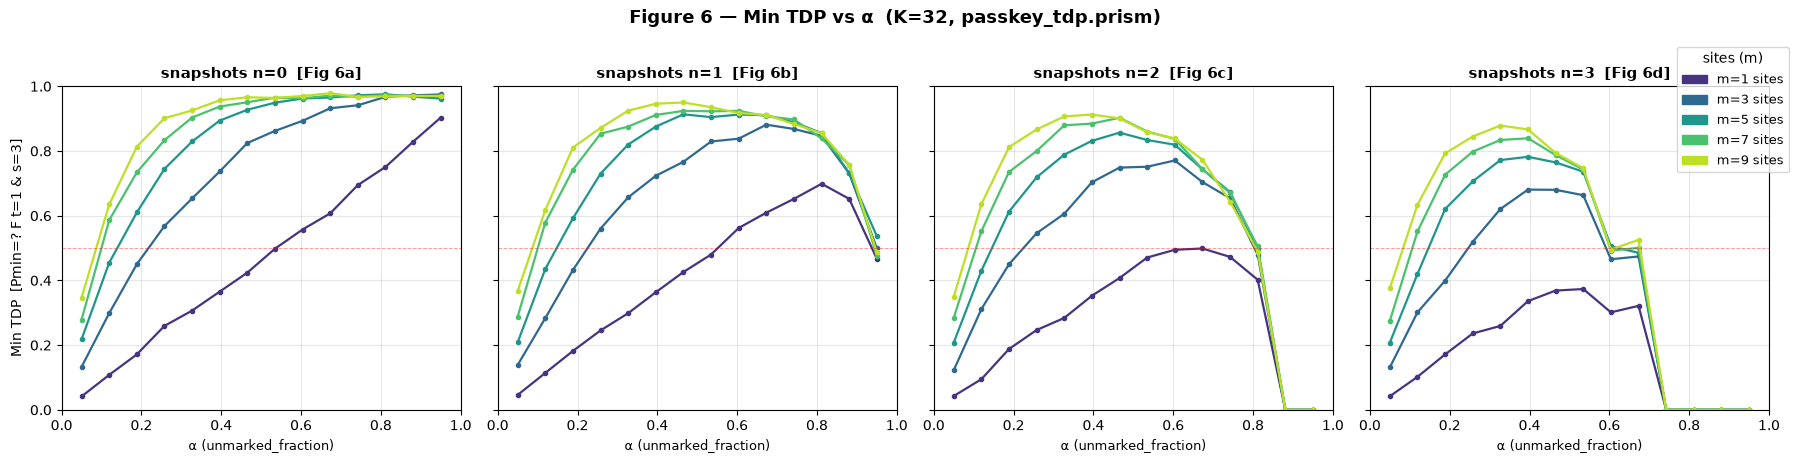

In [10]:
alphas  = np.linspace(0.05, 0.95, 14)
m_vals  = [1, 3, 5, 7, 9]
n_vals  = [0, 1, 2, 3]
N_TR    = 1500
colors  = plt.cm.viridis(np.linspace(0.15, 0.9, len(m_vals)))

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)
for ax, n in zip(axes, n_vals):
    for m, col in zip(m_vals, colors):
        tdps = [simulate_min_tdp(K, a, m, n, N_TR) for a in alphas]
        ax.plot(alphas, tdps, color=col, marker='o', markersize=3, linewidth=1.6)
    ax.set_title(f'snapshots n={n}  [Fig 6{"abcd"[n]}]', fontsize=11, fontweight='bold')
    ax.set_xlabel('α (unmarked_fraction)', fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.axhline(0.5, color='red', linestyle='--', lw=0.7, alpha=0.4, label='TDP=0.5')

axes[0].set_ylabel('Min TDP  [Pmin=? F t=1 & s=3]', fontsize=10)
handles = [mpatches.Patch(color=colors[i], label=f'm={m} sites') for i, m in enumerate(m_vals)]
fig.legend(handles=handles, title='sites (m)', loc='upper right',
           bbox_to_anchor=(1.0, 0.95), fontsize=9)
fig.suptitle(f'Figure 6 — Min TDP vs α  (K={K}, passkey_tdp.prism)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig6_tdp_vs_alpha.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 7. Efficacy — `passkey_eff_std2.prism`

Equation 1 from the paper:
$$\text{eff} = \frac{E(T_{\text{PMS}} \times m) - E((T'_{\text{PMS}} - \tau) \times m')}{E(T_{\text{PMS}} \times m)}$$

`T_PMS ~ Normal(μ=9, σ=2)` months (IBM breach report 2023).  
The MDP chooses optimal τ (delay) and m′ (early stop) to **minimise** eff.

In [11]:
from scipy.stats import norm

def simulate_efficacy(K, alpha, m, lam, sigma, mu=9.0, n_trials=1000):
    tdp = prism_tdp(alpha, K)
    baseline = mu * m
    attacker_total = 0.0
    for _ in range(n_trials):
        T_pms = max(0, np.random.normal(mu, sigma))
        best = 0.0
        for tau in range(int(T_pms) + 1):
            n_obs = np.random.poisson(lam * tau)
            real_p = prism_real(alpha, n_obs, K)
            m_prime = 0
            for _ in range(m):
                is_real = random.random() < real_p
                if not is_real and random.random() < tdp:
                    break
                m_prime += 1
            reward = max(0, T_pms - tau) * m_prime
            best = max(best, reward)
        attacker_total += best
    attacker_mean = attacker_total / n_trials
    return 1.0 - (attacker_mean / baseline) if baseline > 0 else 0.0

# Quick check
e = simulate_efficacy(K=32, alpha=0.6, m=1, lam=0.5, sigma=2.0)
print(f"eff(k=32,alpha=0.6,m=1,lambda=0.5,sigma=2) = {e:.3f}")

eff(k=32,alpha=0.6,m=1,lambda=0.5,sigma=2) = 0.118


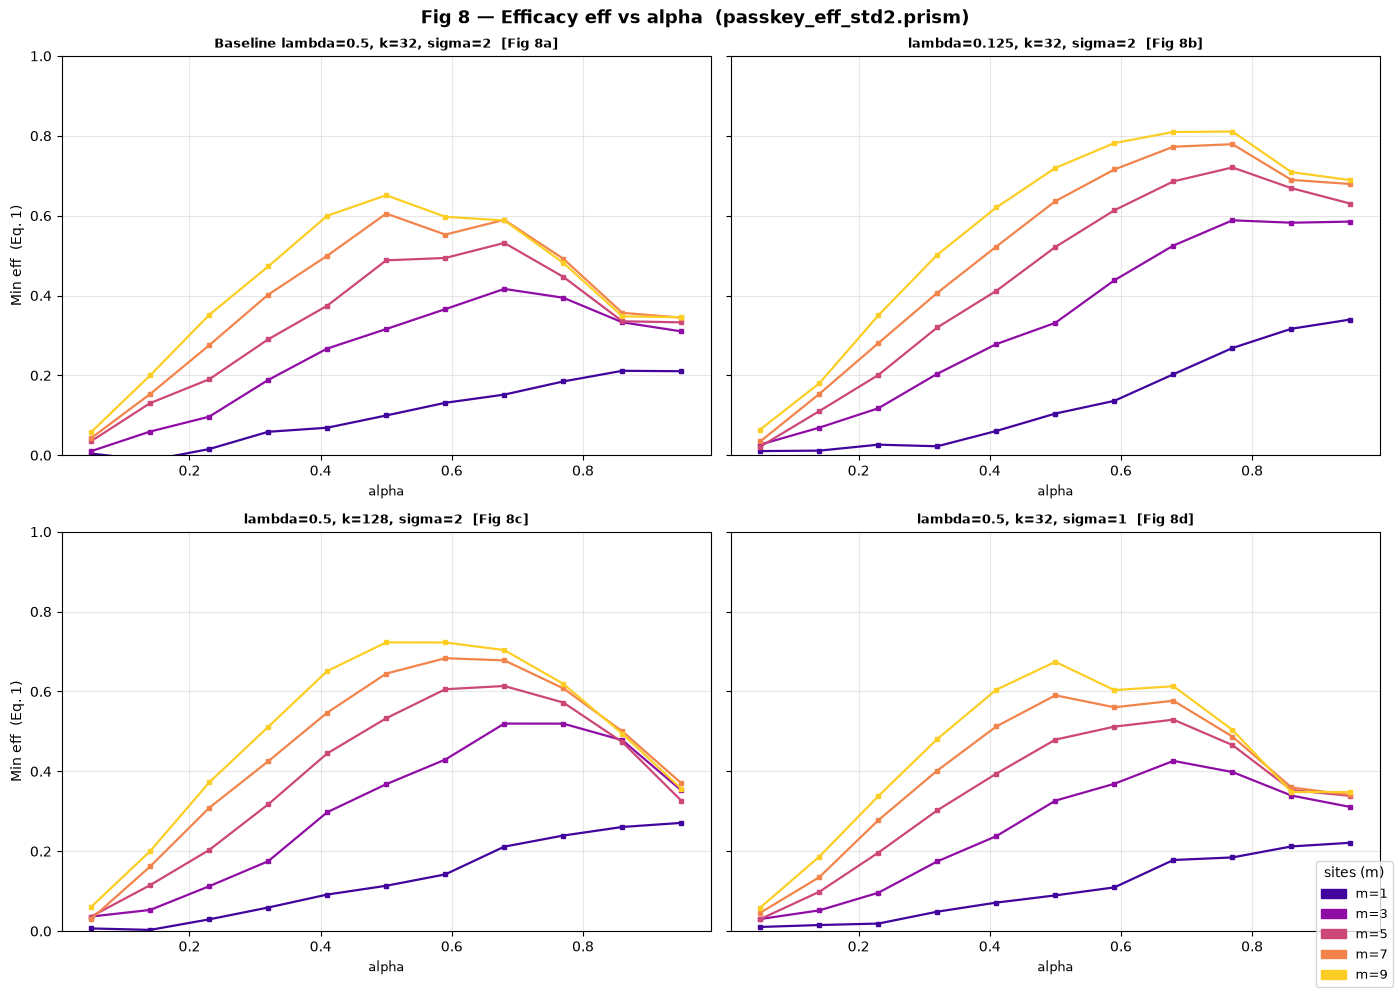

In [12]:
alphas2 = np.linspace(0.05, 0.95, 11)
m_vals2 = [1, 3, 5, 7, 9]
N_EFF   = 600
colors2 = plt.cm.plasma(np.linspace(0.1, 0.9, len(m_vals2)))

configs = [
    (0.5, 32, 2.0, 'Baseline lambda=0.5, k=32, sigma=2  [Fig 8a]'),
    (0.125, 32, 2.0, 'lambda=0.125, k=32, sigma=2  [Fig 8b]'),
    (0.5, 128, 2.0, 'lambda=0.5, k=128, sigma=2  [Fig 8c]'),
    (0.5, 32, 1.0, 'lambda=0.5, k=32, sigma=1  [Fig 8d]'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
for ax, (lam, k_val, sig, title) in zip(axes.flat, configs):
    for m, col in zip(m_vals2, colors2):
        effs = [simulate_efficacy(k_val, a, m, lam, sig, n_trials=N_EFF) for a in alphas2]
        ax.plot(alphas2, effs, color=col, marker='s', markersize=3, linewidth=1.6)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('alpha', fontsize=9)
    ax.set_ylim(0,1); ax.grid(True, alpha=0.3)

for ax in axes[:,0]:
    ax.set_ylabel('Min eff  (Eq. 1)', fontsize=10)
handles2 = [mpatches.Patch(color=colors2[i], label=f'm={m}') for i,m in enumerate(m_vals2)]
fig.legend(handles=handles2, title='sites (m)', loc='lower right', fontsize=9)
fig.suptitle('Fig 8 — Efficacy eff vs alpha  (passkey_eff_std2.prism)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_efficacy.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 8. Statistical Summary — 500 Attack Trials

Run N=500 trials where the attacker uses a random η guess, report ALARM / undetected / failed rates.

Results over 500 attacker trials  (k=32, alpha=0.6):

          Outcome  Count  Rate (%)
ALARM (Detection)    305      61.0
       Undetected    195      39.0
     Login Failed      0       0.0

Expected TDP (PRISM formula) = 0.5818


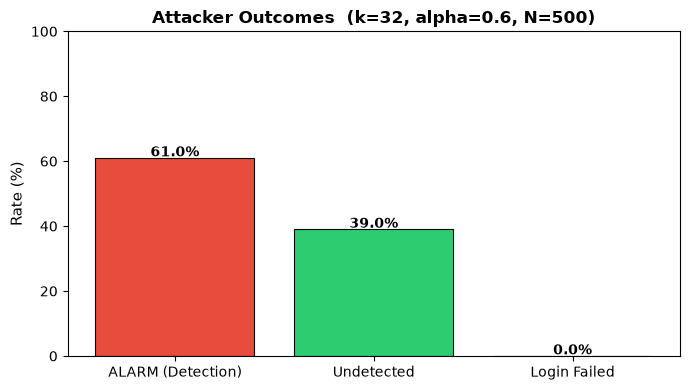

In [13]:
import pandas as pd

N = 500
outcomes = {'ALARM (Detection)': 0, 'Undetected': 0, 'Login Failed': 0}

for _ in range(N):
    W      = GenDetectSecret(K, KAPPA)
    i_star = SelectRealSecret(W, K, 42)
    real_sk = SigningKey.generate(curve=CURVE)
    masked, z = EncCred(W[i_star], real_sk.to_string(), KAPPA)
    creds     = GenVerifierSet(W, masked, z, KAPPA, i_star)
    V_prime   = RandSampleK(creds, ALPHA, i_star)

    # Attacker draws η from the full signed-int32 space — models unlimited credential-stuffing
    eta_att = random.randint(-(2**31), 2**31 - 1)
    i_guess = SelectRealSecret(W, K, eta_att)

    sign_count = 1
    ch_auth    = make_challenge()
    cd_get     = make_client_data(ch_auth, 'webauthn.get')
    ad_auth    = make_auth_data_auth(sign_count)
    sig        = webauthn_sign(creds[i_guess], ad_auth, cd_get)

    if webauthn_verify(creds[i_guess].get_verifying_key(), sig, ad_auth, cd_get):
        if IsActiveDecoyCred(V_prime, i_guess):
            outcomes['ALARM (Detection)'] += 1
        else:
            outcomes['Undetected'] += 1
    else:
        outcomes['Login Failed'] += 1

df = pd.DataFrame(list(outcomes.items()), columns=['Outcome', 'Count'])
df['Rate (%)'] = (df['Count'] / N * 100).round(1)
print(f"Results over {N} attacker trials  (k={K}, alpha={ALPHA}):\n")
print(df.to_string(index=False))
print(f"\nExpected TDP (PRISM formula) = {prism_tdp(ALPHA, K):.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(df['Outcome'], df['Rate (%)'],
              color=['#e74c3c', '#2ecc71', '#95a5a6'], edgecolor='black', lw=0.8)
ax.set_ylabel('Rate (%)', fontsize=11)
ax.set_title(f'Attacker Outcomes  (k={K}, alpha={ALPHA}, N={N})', fontweight='bold')
for bar, val in zip(bars, df['Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('attack_outcomes.png', dpi=120, bbox_inches='tight')
plt.show()

---
## References

- Islam, Arora, Chatterjee, Wang. *Detecting Compromise of Passkey Storage on the Cloud.* USENIX Security 2025.
- Official source: [github.com/islamazhar/CASPER](https://github.com/islamazhar/CASPER) (GPL-3.0)
- PRISM model checker: [prismmodelchecker.org](https://www.prismmodelchecker.org/)

> All functions are Python translations of the authors' Go code in `lib.go`, `casper_login_test.go`, and `casper_detection_test.go`.
> PRISM formulas are copied verbatim from `passkey_tdp.prism` and `passkey_eff_std2.prism`.